# 贝叶斯优化黑盒对抗攻击

## 攻击场景

攻击者只能通过 API 查询模型的 **softmax 概率输出**（黑盒），无法获取模型参数或梯度。目标是找到输入扰动 δ，使得 `model(x + δ) ≠ y`（untargeted 攻击）。

## 方法：PCA 降维 + 贝叶斯优化

- **PCA 降维**：将 3072 维扰动空间压缩到 50 维，降低搜索难度
- **贝叶斯优化**：在 50 维空间中高效搜索，用少量查询找到有效扰动
- **目标函数**：最小化真实类别的 logit 优势 `correct_logit - max_wrong_logit`

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
import numpy as np
from sklearn.decomposition import PCA
from bayes_opt import BayesianOptimization
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

torch.manual_seed(42)
np.random.seed(42)

train_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
attack_device = torch.device("cpu")  # 贝叶斯优化仅支持 CPU

# ==============================
# 黑盒模型：训练后只暴露 softmax 概率
# ==============================
class BlackBoxModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.max_pool2d(x, 2)
        x = torch.relu(self.conv2(x))
        x = torch.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        return torch.softmax(self.fc2(x), dim=1)  # 只返回概率

model = BlackBoxModel().to(train_device)
transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"开始训练黑盒模型（{train_device}）...")
for epoch in range(5):
    running_loss = 0.0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(train_device), labels.to(train_device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(torch.log(outputs + 1e-9), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch + 1}, Loss: {running_loss / len(trainloader):.4f}")

print("黑盒模型训练完成！")
model.to(attack_device)
model.eval()

开始训练黑盒模型（cuda）...
Epoch 1, Loss: 1.5766
Epoch 2, Loss: 1.2652
Epoch 3, Loss: 1.1183
Epoch 4, Loss: 1.0198
Epoch 5, Loss: 0.9418
黑盒模型训练完成！


BlackBoxModel(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

## 攻击实现

### PCA 降维与目标函数

从 softmax 概率反推 logit（未知加性常数不影响 argmax），构造 untargeted 目标函数。

In [2]:
def blackbox_model(x):
    """黑盒 API：只返回 softmax 概率"""
    with torch.no_grad():
        return model(x.to(attack_device))

def estimate_logits(probs):
    """从 softmax 概率反推 logit（减去均值去除未知常数）"""
    log_probs = torch.log(probs + 1e-9)
    return log_probs - log_probs.mean()

def restore_dimensionality(delta_reduced, pca):
    delta_restored = pca.inverse_transform(delta_reduced.reshape(1, -1))
    return delta_restored.reshape(1, 3, 32, 32)

# 扰动幅度（每个 PCA 分量的搜索范围）
DELTA_RANGE = 0.5

def adversarial_objective(pca, x, y, **delta_dict):
    """
    Untargeted 目标函数：最小化 correct_logit - max_wrong_logit。
    返回值越小越好（负值 = 对攻击者有利）。
    """
    delta_reduced = np.array([delta_dict[f'delta_{i}'] for i in range(pca.n_components_)])
    delta = torch.tensor(restore_dimensionality(delta_reduced, pca), dtype=torch.float32).to(x.device)
    x_adv = torch.clamp(x + delta, 0.0, 1.0)

    probs = blackbox_model(x_adv)
    logits = estimate_logits(probs)

    correct_logit = logits[0, y.item()]
    max_wrong_logit = logits[0].max()

    confidence = 0.2  # 允许的置信度裕量
    if max_wrong_logit > correct_logit - confidence:
        return -1.0  # 已满足误分类条件
    else:
        return -(correct_logit - max_wrong_logit).item()  # 负值，越小越好

print("目标函数定义完成")

目标函数定义完成


### 贝叶斯优化搜索

在 50 维 PCA 空间中搜索最优扰动，支持提前终止。

In [3]:
def bayesian_attack(model, x, y, max_queries=500):
    """使用贝叶斯优化搜索对抗扰动"""
    x = x.clone().detach().to(attack_device).to(torch.float32)
    y = y.clone().detach().to(attack_device)

    # PCA 降维：在随机扰动上训练 PCA 基
    num_samples = 100
    delta_samples = np.random.uniform(-DELTA_RANGE, DELTA_RANGE, (num_samples, 3 * 32 * 32))
    pca = PCA(n_components=min(50, num_samples), random_state=42)
    pca.fit(delta_samples)

    pbounds = {f'delta_{i}': (-DELTA_RANGE, DELTA_RANGE) for i in range(pca.n_components_)}

    optimizer = BayesianOptimization(
        f=lambda **kwargs: adversarial_objective(pca, x, y, **kwargs),
        pbounds=pbounds,
        random_state=42,
        verbose=0,
    )

    # 迭代搜索 + 提前终止
    best_so_far = None
    patience = 10
    no_improvement = 0

    for _ in range(max_queries // 11):  # 每次 maximize(init_points=10, n_iter=1) ≈ 11 次查询
        optimizer.maximize(init_points=10, n_iter=1)
        new_best = optimizer.max["target"]

        if best_so_far is None or new_best < best_so_far:
            best_so_far = new_best
            no_improvement = 0
        else:
            no_improvement += 1

        if no_improvement >= patience:
            break

    # 用最优参数构造对抗样本
    best_delta_reduced = np.array([optimizer.max['params'][f'delta_{i}'] for i in range(pca.n_components_)])
    best_delta = torch.tensor(restore_dimensionality(best_delta_reduced, pca), dtype=torch.float32)
    x_adv = torch.clamp(x + best_delta, 0.0, 1.0)

    return x_adv

print("攻击函数定义完成")

攻击函数定义完成


## 运行攻击并评估


--- Attack 1/5 ---
原始预测: 3, 对抗预测: 3, 真实标签: 3
攻击失败


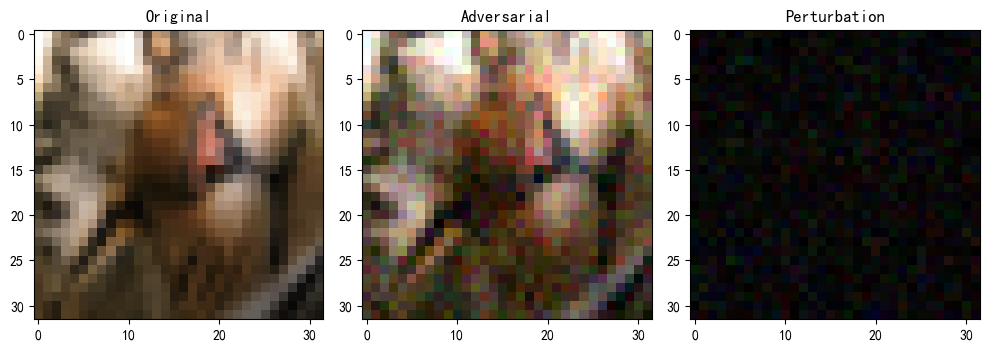


--- Attack 2/5 ---
原始预测: 2, 对抗预测: 2, 真实标签: 2
攻击失败


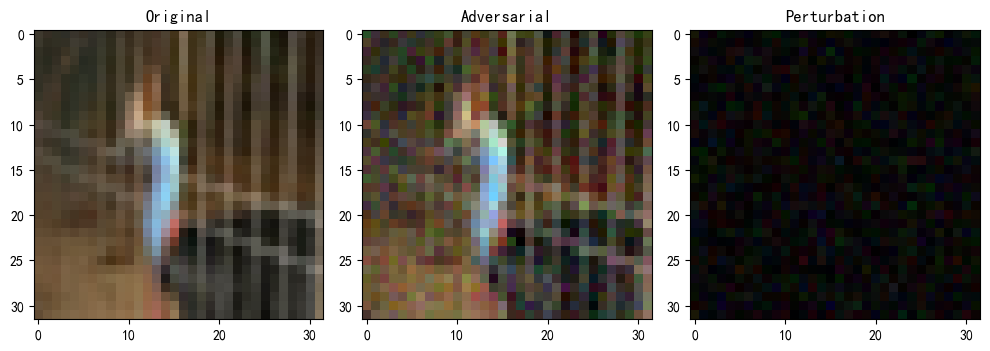


--- Attack 3/5 ---
原始预测: 4, 对抗预测: 6, 真实标签: 4
攻击成功！


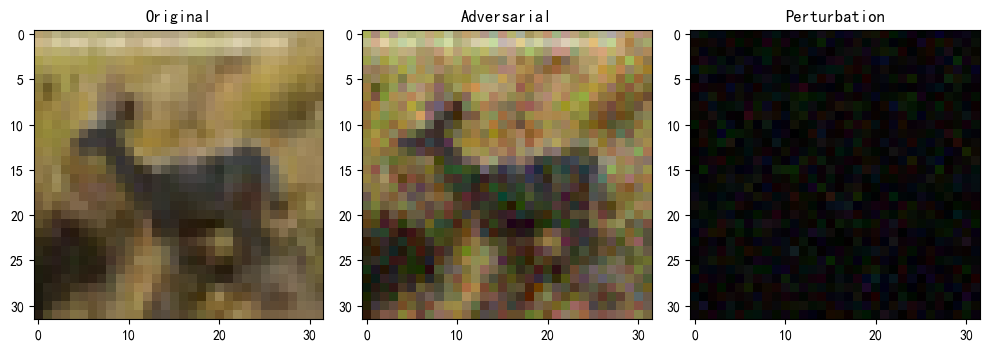


--- Attack 4/5 ---
原始预测: 2, 对抗预测: 4, 真实标签: 2
攻击成功！


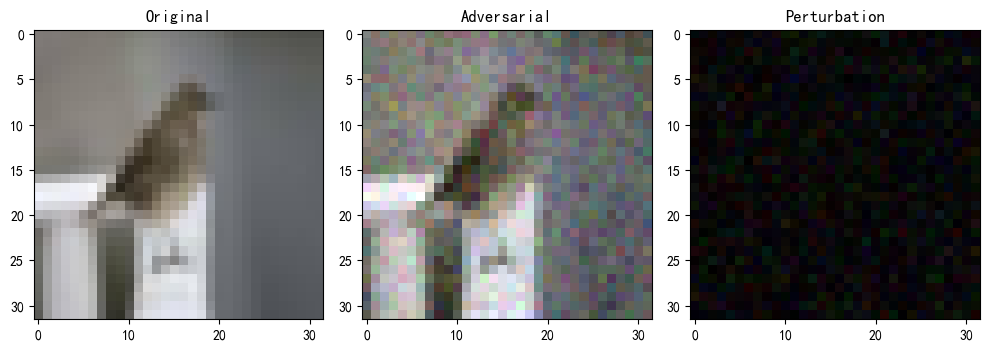


--- Attack 5/5 ---
原始预测: 0, 对抗预测: 0, 真实标签: 0
攻击失败


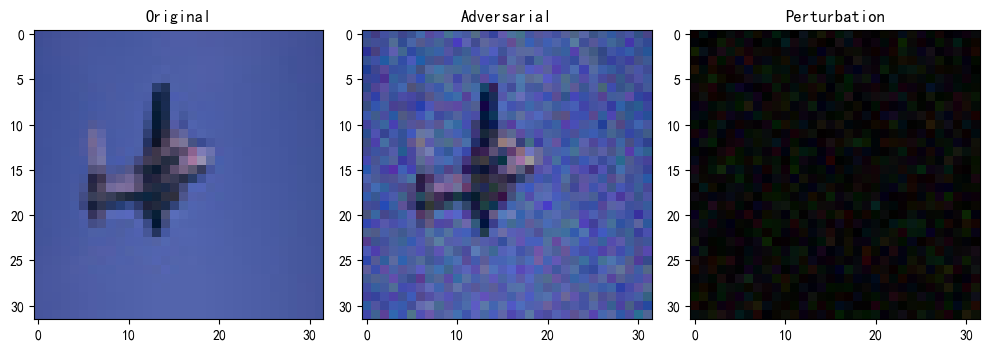


攻击成功率 (ASR): 40.0%


In [4]:
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=1, shuffle=True)

def evaluate_attack(x, x_adv, y):
    pred_orig = blackbox_model(x).argmax(dim=1).item()
    pred_adv = blackbox_model(x_adv).argmax(dim=1).item()
    print(f"原始预测: {pred_orig}, 对抗预测: {pred_adv}, 真实标签: {y.item()}")
    if pred_orig != pred_adv:
        print("攻击成功！")
        return True
    else:
        print("攻击失败")
        return False

def visualize_attack(x, x_adv):
    x_np = x.squeeze(0).permute(1, 2, 0).cpu().numpy()
    x_adv_np = x_adv.squeeze(0).permute(1, 2, 0).cpu().numpy()
    diff = np.abs(x_np - x_adv_np)
    fig, axs = plt.subplots(1, 3, figsize=(10, 4))
    axs[0].imshow(np.clip(x_np, 0, 1)); axs[0].set_title("Original")
    axs[1].imshow(np.clip(x_adv_np, 0, 1)); axs[1].set_title("Adversarial")
    axs[2].imshow(diff); axs[2].set_title("Perturbation")
    plt.tight_layout(); plt.show()

num_attacks = 5
success_count = 0
for i in range(num_attacks):
    print(f"\n--- Attack {i+1}/{num_attacks} ---")
    x, y = next(iter(testloader))
    x, y = x.to(attack_device), y.to(attack_device)
    x_adv = bayesian_attack(model, x, y, max_queries=500)
    if evaluate_attack(x, x_adv, y):
        success_count += 1
    visualize_attack(x, x_adv)

asr = success_count / num_attacks * 100
print(f"\n攻击成功率 (ASR): {asr:.1f}%")

## 解读

### 贝叶斯优化黑盒攻击的工作原理

| 步骤 | 说明 |
|------|------|
| PCA 降维 | 将 3072 维像素扰动压缩到 50 维，让 BO 在低维空间搜索 |
| 目标函数 | 从 softmax 概率反推 logit，最小化真实类别的优势 |
| 贝叶斯优化 | 用高斯过程代理模型高效探索 50 维空间 |
| 提前终止 | 连续 10 轮无改善则停止，节省查询次数 |

### 与其他黑盒攻击的对比

| 方法 | 搜索维度 | 查询效率 | 适用场景 |
|------|---------|---------|---------|
| **贝叶斯优化（本 Notebook）** | 50（PCA） | 中等 | 概率 API |
| **ZOO（Notebook 25）** | 逐坐标 | 高（但查询量大） | 概率 API |
| **SimBA（Notebook 26）** | DCT 基 | 高 | 概率 API |

### 局限性

- PCA 基是随机的，不保证覆盖最优扰动方向
- 扰动幅度（DELTA_RANGE=0.3）较大，肉眼可能可辨
- 贝叶斯优化在高维空间（>20 维）效率下降

### 防御启示

- 限制 API 查询次数可降低黑盒攻击效果
- 对模型输出进行精度压缩（如只返回 top-3）可增加攻击难度
- 差分隐私训练（Notebook 15）可同时防御白盒和黑盒攻击